In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

# from geopy import distance # 거리 계산
# import geopy.distance
from tqdm import tqdm

# 결측치 확인
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

## 데이터 확인하기

In [2]:
df = pd.read_csv('./dataset/2019 관악구 업무추진비.csv')
df.head()

,연번,사용자,사용일시,사용시간,사용금액,사용장소,주소,사용방법,사용내역,집행대상
0,1,의장,2019-01-02,08:44,58500,완산정,서울 관악구 봉천로 484,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 9명
1,2,의장,2019-01-02,12:36,89000,제주은갈치,서울 관악구 관악로 139,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 7명
2,3,의장,2019-01-04,12:53,14000,아리차이,서울 관악구 신림동길 4,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 2명
3,4,의장,2019-01-09,12:33,77000,남원추어탕,서울 관악구 쑥고개로 135,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 7명
4,5,의장,2019-01-09,14:48,83300,카페베네,서울 관악구 남부순환로 2082-29,신용카드,의정활동 및 의회운영 관련 업무휴대경비,의장 등 17명


In [3]:
df.tail()

,연번,사용자,사용일시,사용시간,사용금액,사용장소,주소,사용방법,사용내역,집행대상
1999,101,의회사무국,2019-12-27,20:27,132000,시골집,서울 관악구 낙성대로 22-7,신용카드,의정업무 추진관계자 간담회,사무국장 등 10명
2000,102,의회사무국,2019-12-30,13:00,220000,만리장성,서울 관악구 관악로 146,신용카드,사무국 직원 격려,의정팀장 등 10명
2001,103,의회사무국,2019-12-30,13:08,87000,쌈마을,서울 관악구 남부순환로226길 31,신용카드,의사팀 업무추진 관련 간담회비,의사팀 직원 10명
2002,104,의회사무국,2019-12-30,14:01,174000,장보고마트,서울 관악구 남부순환로230길,신용카드,부서운영 물품(음료) 구입,"의원, 직원, 방문민원인 등"
2003,105,의회사무국,2019-12-30,20:24,123000,제주은갈치,서울 관악구 관악로 139,신용카드,신년인사회 추진 관련 관계자 간담회,의정팀장 등 7명


In [4]:
df.shape

(2004, 10)

In [5]:
df.columns

Index(['연번', '사용자', '사용일시', '사용시간', '사용금액', '사용장소', '주소', '사용방법', '사용내역',
       '집행대상'],
      dtype='object')

In [6]:
df.isnull().sum()

연번        0
사용자       0
사용일시      0
사용시간    452
사용금액      0
사용장소     11
주소       11
사용방법      0
사용내역      0
집행대상     28
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연번      2004 non-null   int64 
 1   사용자     2004 non-null   object
 2   사용일시    2004 non-null   object
 3   사용시간    1552 non-null   object
 4   사용금액    2004 non-null   int64 
 5   사용장소    1993 non-null   object
 6   주소      1993 non-null   object
 7   사용방법    2004 non-null   object
 8   사용내역    2004 non-null   object
 9   집행대상    1976 non-null   object
dtypes: int64(2), object(8)
memory usage: 156.7+ KB


In [8]:
df.sum()

연번                                                  88964
사용자     의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장의장...
사용일시    2019-01-022019-01-022019-01-042019-01-092019-0...
사용금액                                            224074380
사용방법    신용카드신용카드신용카드신용카드신용카드신용카드신용카드신용카드현금신용카드신용카드신용카드...
사용내역    의정활동 및 의회운영 관련 업무휴대경비의정활동 및 의회운영 관련 업무휴대경비의정활동...
dtype: object

In [9]:
df['사용장소'].nunique()

611

In [10]:
df['사용내역'].nunique()

213

+ 총 사용금액 224,074,380 (2억2천~)
+ 장소 611곳

+ 필요한 것
    - 필요없는 컬럼 정리
    - 컬럼 타입 변경
    - 음식점인지 아닌지 구별하기
    - 음식 카테고리 추가하기

## 데이터 전처리하기

+ 필요없는 컬럼 삭제
+ 컬럼 데이터 타입 변경

In [11]:
# 사용방법 컬럼 확인
df['사용방법'].unique()

array(['신용카드', '현금', '제로페이'], dtype=object)

In [12]:
# 사용방법 컬럼 확인
df['사용자'].unique()

array(['의장', '부의장', '의회운영위원장', '행정재경위원장', '보건복지위원장', '도시건설위원장', '관악구의회',
       '의회사무국'], dtype=object)

### 사용일시 컬럼

In [13]:
# 사용일시 컬럼 날짜타입으로 변경
df['사용일시'] = pd.to_datetime(df['사용일시'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   연번      2004 non-null   int64         
 1   사용자     2004 non-null   object        
 2   사용일시    2004 non-null   datetime64[ns]
 3   사용시간    1552 non-null   object        
 4   사용금액    2004 non-null   int64         
 5   사용장소    1993 non-null   object        
 6   주소      1993 non-null   object        
 7   사용방법    2004 non-null   object        
 8   사용내역    2004 non-null   object        
 9   집행대상    1976 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 156.7+ KB


### 결측치 확인 및 처리

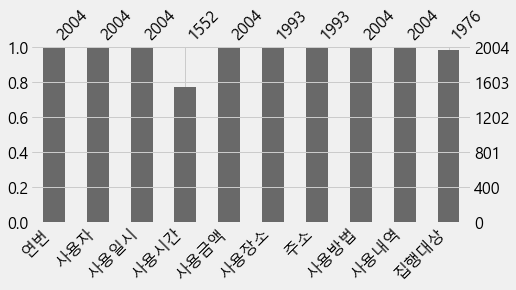

In [15]:
# 먼저 결측값 얼마나 있는지 확인해보기
msno.bar(df, figsize=(7, 3))
plt.show()

In [16]:
df.isnull().sum()

연번        0
사용자       0
사용일시      0
사용시간    452
사용금액      0
사용장소     11
주소       11
사용방법      0
사용내역      0
집행대상     28
dtype: int64

In [17]:
# 사용시간 결측치 확인
df[df['사용시간'].isnull()]

,연번,사용자,사용일시,사용시간,사용금액,사용장소,주소,사용방법,사용내역,집행대상
8,9,의장,2019-01-11,NaN,50000,NaN,NaN,현금,의회운영 경조사비 지출,안OO 주무관
215,22,의장,2019-03-25,NaN,50000,NaN,NaN,현금,의장 의회운영업무추진비 경조사비 지출,김OO 주무관 빙부상 경조사금
370,87,관악구의회,2019-04-26,NaN,1200000,NaN,NaN,현금,강원도 산불 피해지원 성금 납부,재해구호협회
705,16,의장,2019-08-16,NaN,50000,NaN,NaN,현금,의장 의회운영업무추진비 경조사비,관악구의회 의원
907,13,의장,2019-10-18,NaN,50000,NaN,NaN,현금,의장 의회운영업무추진비 경조사비 지출,사무국 직원 1명
...,...,...,...,...,...,...,...,...,...,...
1592,57,의회사무국,2019-07-31,NaN,89500,심가면옥,서울시 관악구 신림로 121,제로페이,의정업무 추진관계자 간담회,사무국장 등 8명
1593,58,의회사무국,2019-07-31,NaN,290000,시골집,서울 관악구 낙성대로 22-7,제로페이,사무국 직원 격려,의정팀장 등 19명
1627,34,의회사무국,2019-08-16,NaN,50000,NaN,NaN,현금,기관운영업무추진비 경조사비,관악구의회 의원
1782,45,의회사무국,2019-10-18,NaN,50000,NaN,NaN,현금,기관운영업무추진비 경조사비 지출,의회사무국 직원


In [18]:
# 사용장소 결측치 확인
df[df['사용장소'].isnull()]

,연번,사용자,사용일시,사용시간,사용금액,사용장소,주소,사용방법,사용내역,집행대상
8,9,의장,2019-01-11,NaN,50000,NaN,NaN,현금,의회운영 경조사비 지출,안OO 주무관
215,22,의장,2019-03-25,NaN,50000,NaN,NaN,현금,의장 의회운영업무추진비 경조사비 지출,김OO 주무관 빙부상 경조사금
370,87,관악구의회,2019-04-26,NaN,1200000,NaN,NaN,현금,강원도 산불 피해지원 성금 납부,재해구호협회
705,16,의장,2019-08-16,NaN,50000,NaN,NaN,현금,의장 의회운영업무추진비 경조사비,관악구의회 의원
907,13,의장,2019-10-18,NaN,50000,NaN,NaN,현금,의장 의회운영업무추진비 경조사비 지출,사무국 직원 1명
996,2,의장,2019-11-01,NaN,50000,NaN,NaN,현금,의회운영업무추진비 경조사비,의원 1명
1176,26,의회사무국,2019-01-11,NaN,50000,NaN,NaN,현금,기관운영 경조사비 지출,안OO 주무관
1312,50,의회사무국,2019-03-25,NaN,50000,NaN,NaN,현금,기관운영 업무추진비 경조사비 지출,김OO 주무관 빙부상 경조사금
1627,34,의회사무국,2019-08-16,NaN,50000,NaN,NaN,현금,기관운영업무추진비 경조사비,관악구의회 의원
1782,45,의회사무국,2019-10-18,NaN,50000,NaN,NaN,현금,기관운영업무추진비 경조사비 지출,의회사무국 직원


In [19]:
# 집행대상 결측치 확인
df[df['집행대상'].isnull()]

,연번,사용자,사용일시,사용시간,사용금액,사용장소,주소,사용방법,사용내역,집행대상
1276,14,의회사무국,2019-03-07,NaN,17500,다이소,서울 관악구 남부순환로 1840,신용카드,부서운영 필요 물품 구입,NaN
1335,8,의회사무국,2019-04-04,NaN,260000,진진식품,서울 관악구 난곡로 168,신용카드,의원 워크숍 사전준비 간식류 구입,NaN
1368,41,의회사무국,2019-04-16,NaN,195900,장보고마트,서울 관악구 남부순환로230길,신용카드,창녕군협약식 추진관련 간담회 다과 및 행사용품 구입,NaN
1369,42,의회사무국,2019-04-16,NaN,6000,다이소,서울 강남구 남부순환로 2748,신용카드,창녕군협약식 행사관련 종이컵 구매,NaN
1370,43,의회사무국,2019-04-16,NaN,39100,파리바게뜨,서울 관악구 봉천동,신용카드,창녕군협약식 추진관련 간담회 다과 구입,NaN
1371,44,의회사무국,2019-04-16,NaN,48000,김가네,서울 관악구 관악로 152,신용카드,창녕군협약식 참석 의원 및 수행직원 조식 구매,NaN
1392,65,의회사무국,2019-04-26,NaN,271500,장보고마트,서울 관악구 남부순환로230길,신용카드,강릉기관방문 관련 다과 및 행사용품 구입,NaN
1393,66,의회사무국,2019-04-26,NaN,4000,다이소,서울 강남구 남부순환로 2748,신용카드,강릉기관방문 행사관련 종이컵 구매,NaN
1394,67,의회사무국,2019-04-26,NaN,84000,태창약국,서울 관악구 쑥고개로 126-1,신용카드,강릉기관 방문 관련 비상약품 구매,NaN
1459,51,의회사무국,2019-05-22,NaN,172600,롯데리아（백령도점）,서울시 중구 세종대로 39,신용카드,의원워크숍 군부대 안보교육 관련 장병 위문간식 구매,NaN


+ 사용장소, 주소 결측치는 제거해도 된다.
+ 사용시간, 집행대상은 유의미한 데이터가 있어 컬럼만 삭제.

In [20]:
# 연번, 사용시간, 사용방법, 집행대상 컬럼 삭제
df = df.drop(['연번', '사용시간', '사용방법', '집행대상'], axis=1)
df.head()

,사용자,사용일시,사용금액,사용장소,주소,사용내역
0,의장,2019-01-02,58500,완산정,서울 관악구 봉천로 484,의정활동 및 의회운영 관련 업무휴대경비
1,의장,2019-01-02,89000,제주은갈치,서울 관악구 관악로 139,의정활동 및 의회운영 관련 업무휴대경비
2,의장,2019-01-04,14000,아리차이,서울 관악구 신림동길 4,의정활동 및 의회운영 관련 업무휴대경비
3,의장,2019-01-09,77000,남원추어탕,서울 관악구 쑥고개로 135,의정활동 및 의회운영 관련 업무휴대경비
4,의장,2019-01-09,83300,카페베네,서울 관악구 남부순환로 2082-29,의정활동 및 의회운영 관련 업무휴대경비


In [21]:
# 결측치 제거
df.dropna(inplace=True)

In [22]:
# 확인
df.isnull().sum()

사용자     0
사용일시    0
사용금액    0
사용장소    0
주소      0
사용내역    0
dtype: int64

In [23]:
df.shape

(1993, 6)

### 사용장소 전처리

In [24]:
for i in df.index:
    if df.loc[i, '사용장소']=='GS슈퍼':
        df.loc[i, '사용장소'] = 'GS슈퍼마켓'
    elif df.loc[i, '사용장소']=='강강술래신림본동점':
        df.loc[i, '사용장소'] = '강강술래'
    elif df.loc[i, '사용장소']=='강촌민물매운탕２호점':
        df.loc[i, '사용장소'] = '강촌민물매운탕2호점'
    elif df.loc[i, '사용장소']=='고봉민김밥인':
        df.loc[i, '사용장소'] = '고봉민김밥'
    elif df.loc[i, '사용장소']=='김가네 관악구청점':
        df.loc[i, '사용장소'] = '김가네'

    
    
    elif df.loc[i, '사용장소']=='동강영양탕':
        df.loc[i, '사용장소'] = '동강염소탕'
    elif df.loc[i, '사용장소']=='맛고을칼국수＆찰보리':
        df.loc[i, '사용장소'] = '맛고을칼국수＆찰보리밥'
    elif df.loc[i, '사용장소']=='먹쉬돈나 서울대역점':
        df.loc[i, '사용장소'] = '먹쉬돈나'
    elif df.loc[i, '사용장소']=='명태어장(서울대점)':
        df.loc[i, '사용장소'] = '명태어장'
    elif df.loc[i, '사용장소']=='명품청기와감자탕미성점':
        df.loc[i, '사용장소'] = '명품청기와감자탕'
    elif df.loc[i, '사용장소']=='미가할매참품한우':
        df.loc[i, '사용장소'] = '미가할매집'
    elif df.loc[i, '사용장소']=='바우네나주곰탕　봉천':
        df.loc[i, '사용장소'] = '바우네나주곰탕'
        

        
        
    elif df.loc[i, '사용장소']=='봉이 구이대장':
        df.loc[i, '사용장소'] = '봉이구이대장'
    elif df.loc[i, '사용장소']=='사시사철흑염소.오리':
        df.loc[i, '사용장소'] = '사시사철흑염소오리'
        
        

    
    elif (df.loc[i, '사용장소']=='엔조파스타&피자') or (df.loc[i, '사용장소']=='ENZO(엔조)'):
        df.loc[i, '사용장소'] = '엔조 파스타&피자'
        
        
    elif (df.loc[i, '사용장소']=='영광수산장어1번가') or (df.loc[i, '사용장소']=='영광수산장어１번가'):
        df.loc[i, '사용장소'] = '영광수산숯불민물장어'
    
    
    elif (df.loc[i, '사용장소']=='이대감명품막창') or (df.loc[i, '사용장소']=='이대감왕족발'):
        df.loc[i, '사용장소'] = '이대감 명품막창'
    
    elif (df.loc[i, '사용장소']=='일커피　서울대입구점') or (df.loc[i, '사용장소']=='일커피 서울대입구점'):
        df.loc[i, '사용장소'] = '일커피'
                                            
    elif (df.loc[i, '사용장소']=='자연별곡 서울대입구점') or (df.loc[i, '사용장소']=='자연별곡서울대입구점'):
        df.loc[i, '사용장소'] = '자연별곡'
    
    elif (df.loc[i, '사용장소']=='작은따옴표 협동조합') or (df.loc[i, '사용장소']=='작은따옴표협동조합'):
        df.loc[i, '사용장소'] = '작은따옴표'
        
    elif (df.loc[i, '사용장소']=='커피빈') or (df.loc[i, '사용장소']=='커피빈코리아인'):
        df.loc[i, '사용장소'] = '커피빈코리아'
        
    elif (df.loc[i, '사용장소']=='콩심 서울대점') or (df.loc[i, '사용장소']=='콩심서울대점'):
        df.loc[i, '사용장소'] = '콩심'
        
        
    
    elif df.loc[i, '사용장소']=='종로계림닭도리탕':
        df.loc[i, '사용장소'] = '종로계림닭도리탕원조'
        
    elif df.loc[i, '사용장소']=='진부령　황태촌':
        df.loc[i, '사용장소'] = '진부령황태촌'    
    
    elif df.loc[i, '사용장소']=='진우리참치':
        df.loc[i, '사용장소'] = '진우리독도참치'    
        
    elif df.loc[i, '사용장소']=='카페모아관악구청점':
        df.loc[i, '사용장소'] = '카페모아'    
    
    elif df.loc[i, '사용장소']=='쿠팡㈜':
        df.loc[i, '사용장소'] = '쿠팡'       
    
    elif df.loc[i, '사용장소']=='태창약국':
        df.loc[i, '사용장소'] = '태창온누리약국'     
    
    elif df.loc[i, '사용장소']=='투썸플레이스':
        df.loc[i, '사용장소'] = '투썸서울대입구역'       
        
        
    elif (df.loc[i, '사용장소']=='난곡문성파리바게뜨') or (df.loc[i, '사용장소']=='난곡사거리 파리바게뜨'):
        df.loc[i, '사용장소'] = '파리바게뜨'
    
    elif (df.loc[i, '사용장소']=='서울대 파리바게뜨') or (df.loc[i, '사용장소']=='서울대입구역2호 파리바게뜨'):
        df.loc[i, '사용장소'] = '파리바게뜨'
    elif (df.loc[i, '사용장소']=='은천길입구 파리바게뜨') or (df.loc[i, '사용장소']=='파리바게뜨서울대입구'):
        df.loc[i, '사용장소'] = '파리바게뜨'
    elif (df.loc[i, '사용장소']=='파리바게트'):
        df.loc[i, '사용장소'] = '파리바게뜨'
    
    elif (df.loc[i, '사용장소']=='본죽 관악구청점') or (df.loc[i, '사용장소']=='본죽&본도시락'):
        df.loc[i, '사용장소'] = '본죽'
    elif (df.loc[i, '사용장소']=='본죽&비빔밥') or (df.loc[i, '사용장소']=='본죽봉천점'):
        df.loc[i, '사용장소'] = '본죽'   
    elif (df.loc[i, '사용장소']=='본죽＆비빔밥') or (df.loc[i, '사용장소']=='본죽＆비빔밥ｃａｆｅ'):
        df.loc[i, '사용장소'] = '본죽'
          
          
    elif (df.loc[i, '사용장소']=='서울대학교생협호암교수회관') or (df.loc[i, '사용장소']=='서울대학교생활협동조'):
        df.loc[i, '사용장소'] = '서울대학교'
          
          
    elif (df.loc[i, '사용장소']=='스타벅스 서울대입구역점'):
        df.loc[i, '사용장소'] = '스타벅스'
    
    elif (df.loc[i, '사용장소']=='아웃백') or (df.loc[i, '사용장소']=='아웃백스테이크'):
        df.loc[i, '사용장소'] = '아웃백스테이크하우스'
    
    elif (df.loc[i, '사용장소']=='삼백돈'):
        df.loc[i, '사용장소'] = '삼백돈돈가츠'      
    elif (df.loc[i, '사용장소']=='두부이야기봉천점'):
        df.loc[i, '사용장소'] = '두부이야기'
    elif (df.loc[i, '사용장소']=='얼큰수제비') or (df.loc[i, '사용장소']=='얼큰수제비 해물칼국수'):
        df.loc[i, '사용장소'] = '얼큰수제비해물칼국수'
        
    elif (df.loc[i, '사용장소']=='얼큰수제비') or (df.loc[i, '사용장소']=='얼큰수제비 해물칼국수'):
        df.loc[i, '사용장소'] = '얼큰수제비해물칼국수'
    elif (df.loc[i, '사용장소']=='풍년오리'):
        df.loc[i, '사용장소'] = '풍년옥'

In [25]:
df['사용장소'].value_counts()

제주은갈치       93
시골집         45
옥천골         40
감나무집        33
파리바게뜨       33
            ..
더고기서울대맛집     1
전주민속촌        1
SOME801      1
테라스          1
진갈비          1
Name: 사용장소, Length: 556, dtype: int64

+ 사용장소를 557개로 좁힘.

### 데이터 저장하기

In [26]:
# df.to_csv('./dataset/업무추진비_전체_20220316.csv', index=False)

## 사용장소 컬럼별 데이터 확인하기

In [27]:
df1 = df.value_counts('사용장소').reset_index().sort_values('사용장소')
df1.reset_index(inplace=True)
df1.drop('index', axis=1, inplace=True)
df1

,사용장소,0
0,#207,2
1,(주)소명생고기,1
2,(주)송원마포갈비,1
3,(주)신세계페이먼츠,4
4,(주)신화아이푸드,1
...,...,...
551,흥부보쌈,8
552,희로애락,2
553,희전명가,1
554,히포커피,1


In [28]:
df2 = df.groupby('사용장소').sum()
df2.reset_index(inplace=True)
df2

,사용장소,사용금액
0,#207,27200
1,(주)소명생고기,100000
2,(주)송원마포갈비,45500
3,(주)신세계페이먼츠,546290
4,(주)신화아이푸드,469500
...,...,...
551,흥부보쌈,1167000
552,희로애락,508000
553,희전명가,88000
554,히포커피,10800


In [29]:
for i in range(len(df2)):
    if df2.loc[i, '사용장소']==df1.loc[i, '사용장소']:
        df2.loc[i, '방문횟수'] = df1.loc[i, 0]

In [30]:
df2.isnull().sum()

사용장소    0
사용금액    0
방문횟수    0
dtype: int64

In [31]:
# 방문횟수 int로 변경
df2['방문횟수'] = df2['방문횟수'].astype('int')
df2.head()

,사용장소,사용금액,방문횟수
0,#207,27200,2
1,(주)소명생고기,100000,1
2,(주)송원마포갈비,45500,1
3,(주)신세계페이먼츠,546290,4
4,(주)신화아이푸드,469500,1


In [32]:
df2.sort_values('방문횟수', ascending=False).head(30)

,사용장소,사용금액,방문횟수
431,제주은갈치,11714000,93
285,시골집,9381000,45
346,옥천골,6801000,40
79,남원추어탕,3146000,33
506,파리바게뜨,1125300,33
23,감나무집,6527500,33
239,산야로,1916000,31
338,오리오리,2076000,31
298,쌈마을,4350000,26
334,옛날육개장,2664000,26


In [33]:
df2 = df2[['사용장소', '방문횟수', '사용금액']]
df2

,사용장소,방문횟수,사용금액
0,#207,2,27200
1,(주)소명생고기,1,100000
2,(주)송원마포갈비,1,45500
3,(주)신세계페이먼츠,4,546290
4,(주)신화아이푸드,1,469500
...,...,...,...
551,흥부보쌈,8,1167000
552,희로애락,2,508000
553,희전명가,1,88000
554,히포커피,1,10800


### 데이터 저장하기

In [34]:
# df2.to_csv('./dataset/업무추진비_사용장소별_556.csv', index=False)

+ 잘못 기재된 데이터들을 확인하는 작업이 필요하다.

In [35]:
len(df2[df2['방문횟수']>3])

127

## 사용자 컬럼별 데이터 확인하기

In [36]:
df['사용자'].unique()

array(['의장', '부의장', '의회운영위원장', '행정재경위원장', '보건복지위원장', '도시건설위원장', '의회사무국'],
      dtype=object)

In [37]:
df_user_1 = df[df['사용자']=='의장']['사용장소'].value_counts().reset_index()
df_user_1 = df_user_1.sort_values('index').reset_index().drop('level_0', axis=1)
df_user_1

,index,사용장소
0,감나무집,18
1,강강술래,7
2,강촌민물매운탕2호점,1
3,개성보쌈,1
4,갯벌낙지,1
...,...,...
60,파리바게뜨,3
61,풍천장어,1
62,하이보,4
63,한류관,1


In [38]:
df_user_2 = df[df['사용자']=='의장'].groupby('사용장소').sum().reset_index()

for i in df_user_1.index:
    if df_user_2.loc[i, '사용장소'] == df_user_1.loc[i, 'index']:
        df_user_2.loc[i, '방문횟수'] = df_user_1.loc[i, '사용장소']

df_user_2['방문횟수'] = df_user_2['방문횟수'].astype('int')
df_user_2 = df_user_2[['사용장소', '방문횟수', '사용금액']]

df_user_2.sort_values('방문횟수', ascending=False).head()

,사용장소,방문횟수,사용금액
50,제주은갈치,33,4435000
44,우리동네고기집,22,7319900
0,감나무집,18,3137000
24,생각보다맛있는집,16,1005000
8,남원추어탕,15,1610000


### 함수 만들어보기

In [39]:
def df_user(user):
    df_user_1 = df[df['사용자']==user]['사용장소'].value_counts().reset_index()
    df_user_1 = df_user_1.sort_values('index').reset_index().drop('level_0', axis=1)
    
    df_user_2 = df[df['사용자']==user].groupby('사용장소').sum().reset_index()

    for i in df_user_1.index:
        if df_user_2.loc[i, '사용장소'] == df_user_1.loc[i, 'index']:
            df_user_2.loc[i, '방문횟수'] = df_user_1.loc[i, '사용장소']

    df_user_2['방문횟수'] = df_user_2['방문횟수'].astype('int')
    df_user_2 = df_user_2[['사용장소', '방문횟수', '사용금액']]

    return df_user_2.sort_values('방문횟수', ascending=False).head()

In [40]:
df_user('의장')

,사용장소,방문횟수,사용금액
50,제주은갈치,33,4435000
44,우리동네고기집,22,7319900
0,감나무집,18,3137000
24,생각보다맛있는집,16,1005000
8,남원추어탕,15,1610000


In [41]:
df_user('부의장')

,사용장소,방문횟수,사용금액
80,은성숯불갈비,19,1867100
20,당곡기사식당,11,846000
6,고창복의낙지세상,10,913000
7,구수옥설렁탕,9,586000
66,아리차이,7,1247000


In [42]:
df_user('의회운영위원장')

,사용장소,방문횟수,사용금액
17,다리목,11,2560000
38,북경반점,7,763000
61,장터순대국,5,743000
26,명품횡성한우가,5,602000
9,김밥,5,1021000


In [43]:
df_user('행정재경위원장')

,사용장소,방문횟수,사용금액
87,통큰대박집,10,2435000
74,전진식당,10,314000
8,거목쟁반짜장,8,136500
85,콩심,8,136000
15,금비,6,1749000


In [44]:
df_user('보건복지위원장')

,사용장소,방문횟수,사용금액
34,옥천골,37,6065000
49,제주은갈치,20,3097000
2,감나무집,6,1026000
47,정육점식당,5,227000
20,목포부부아구찜,5,580000


In [45]:
df_user('도시건설위원장')

,사용장소,방문횟수,사용금액
98,파리바게뜨,8,281400
109,흥부보쌈,5,666000
45,사랑방,5,951000
25,만리장성,5,384500
1,감나무집,5,1684500


In [46]:
df_user('의회사무국')

,사용장소,방문횟수,사용금액
112,시골집,33,6855000
88,산야로,29,1867000
173,제주은갈치,29,3661000
133,오리오리,29,1949000
162,장보고마트,25,6522210


## 사용일시 컬럼으로 데이터 확인하기

+ 시계열 그래프 그려보기
+ 월별 사용 금액 확인하기 -> 년월 컬럼 추가
+ 계절별 사용 금액 확인하기 -> 계절 컬럼 추가

In [47]:
df

,사용자,사용일시,사용금액,사용장소,주소,사용내역
0,의장,2019-01-02,58500,완산정,서울 관악구 봉천로 484,의정활동 및 의회운영 관련 업무휴대경비
1,의장,2019-01-02,89000,제주은갈치,서울 관악구 관악로 139,의정활동 및 의회운영 관련 업무휴대경비
2,의장,2019-01-04,14000,아리차이,서울 관악구 신림동길 4,의정활동 및 의회운영 관련 업무휴대경비
3,의장,2019-01-09,77000,남원추어탕,서울 관악구 쑥고개로 135,의정활동 및 의회운영 관련 업무휴대경비
4,의장,2019-01-09,83300,카페베네,서울 관악구 남부순환로 2082-29,의정활동 및 의회운영 관련 업무휴대경비
...,...,...,...,...,...,...
1999,의회사무국,2019-12-27,132000,시골집,서울 관악구 낙성대로 22-7,의정업무 추진관계자 간담회
2000,의회사무국,2019-12-30,220000,만리장성,서울 관악구 관악로 146,사무국 직원 격려
2001,의회사무국,2019-12-30,87000,쌈마을,서울 관악구 남부순환로226길 31,의사팀 업무추진 관련 간담회비
2002,의회사무국,2019-12-30,174000,장보고마트,서울 관악구 남부순환로230길,부서운영 물품(음료) 구입


### 시계열 그래프 그려보기

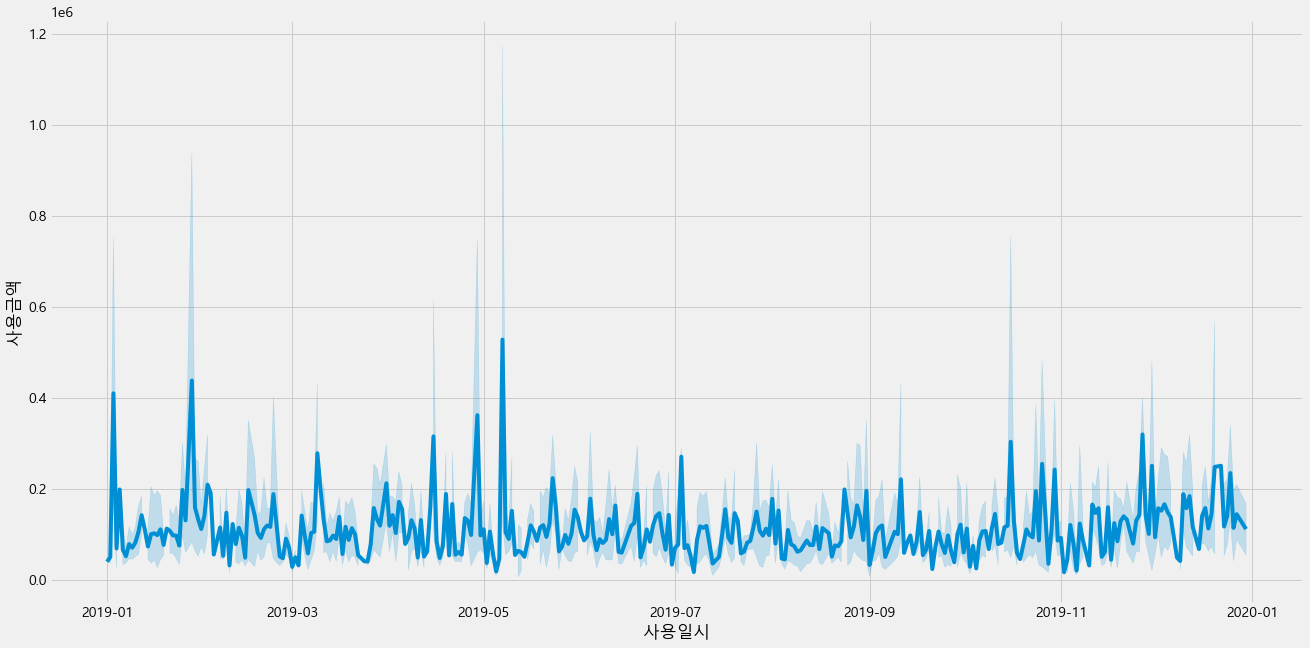

In [48]:
# 년월일 시계열 그래프
plt.figure(figsize=(20, 10))
sns.lineplot(x='사용일시', y='사용금액', data=df)
plt.show()

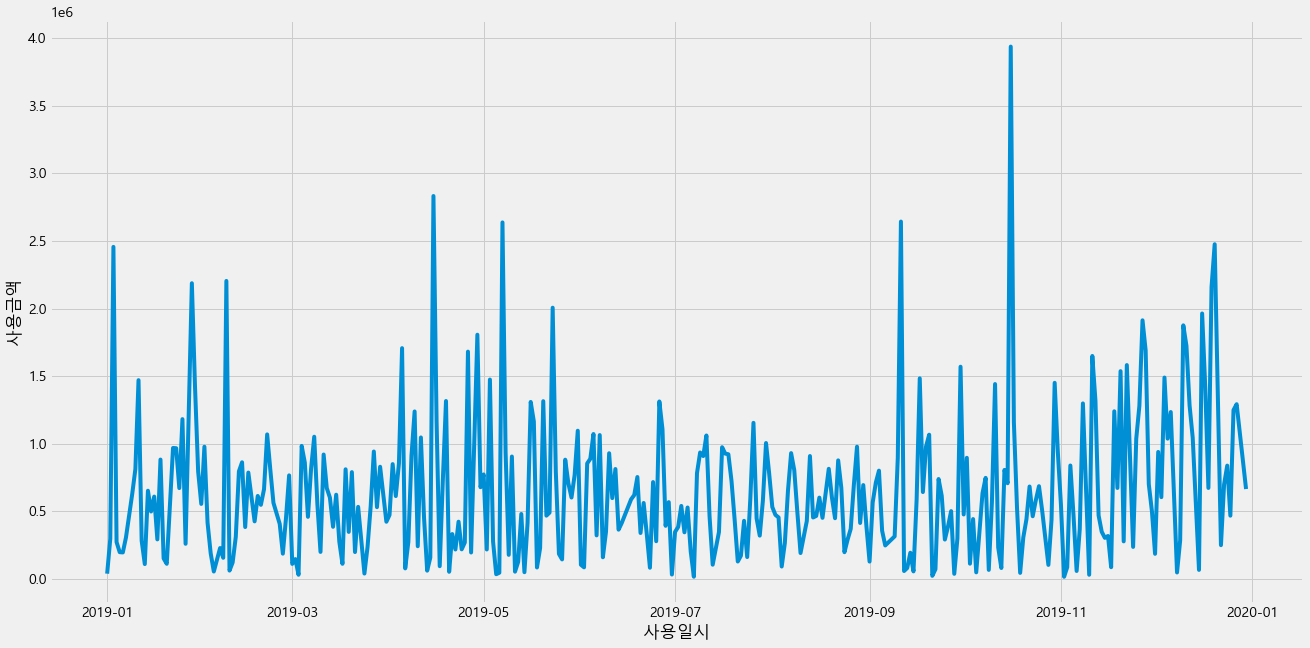

In [49]:
df.groupby('사용일시').sum().reset_index()

plt.figure(figsize=(20, 10))
sns.lineplot(x='사용일시', y='사용금액', data=df.groupby('사용일시').sum().reset_index())
plt.show()

### 년월 컬럼 추가하기

In [50]:
df['사용년월'] = df['사용일시'].dt.strftime('%Y-%m')
df.head()

,사용자,사용일시,사용금액,사용장소,주소,사용내역,사용년월
0,의장,2019-01-02,58500,완산정,서울 관악구 봉천로 484,의정활동 및 의회운영 관련 업무휴대경비,2019-01
1,의장,2019-01-02,89000,제주은갈치,서울 관악구 관악로 139,의정활동 및 의회운영 관련 업무휴대경비,2019-01
2,의장,2019-01-04,14000,아리차이,서울 관악구 신림동길 4,의정활동 및 의회운영 관련 업무휴대경비,2019-01
3,의장,2019-01-09,77000,남원추어탕,서울 관악구 쑥고개로 135,의정활동 및 의회운영 관련 업무휴대경비,2019-01
4,의장,2019-01-09,83300,카페베네,서울 관악구 남부순환로 2082-29,의정활동 및 의회운영 관련 업무휴대경비,2019-01


In [51]:
df.groupby('사용년월').sum()

,사용금액
사용년월,
2019-01,20284810
2019-02,14056730
2019-03,15029600
2019-04,20979920
2019-05,20850600
2019-06,15708240
2019-07,16732640
2019-08,15648850
2019-09,16351510


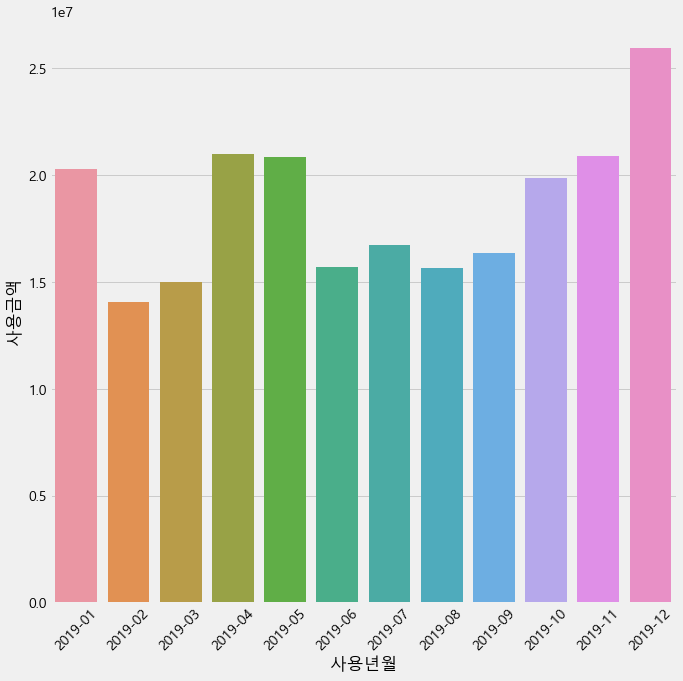

In [52]:
# 바 그래프
plt.figure(figsize=(10, 10))
sns.barplot(x='사용년월', y='사용금액', data=df.groupby('사용년월').sum().reset_index())
plt.xticks(rotation=45)
plt.show()

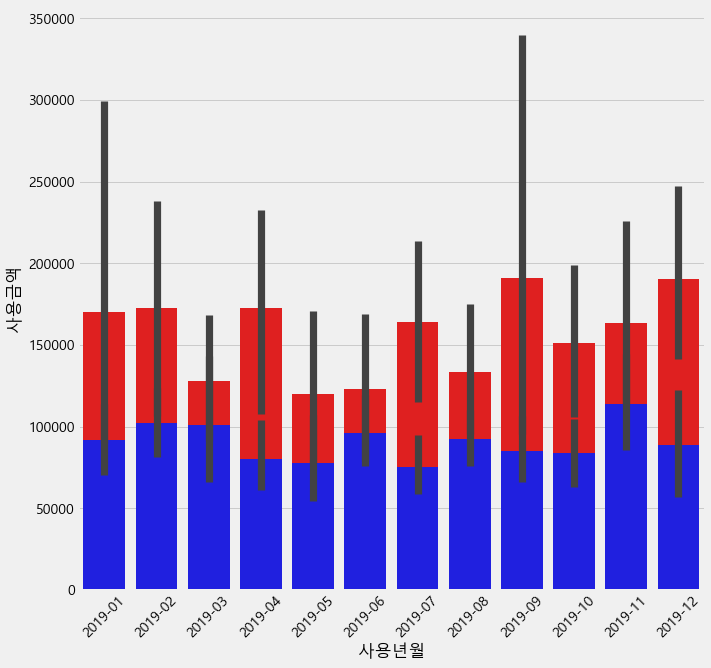

In [53]:
# 바 그래프
plt.figure(figsize=(10, 10))
sns.barplot(x='사용년월', y='사용금액', data=df[df['사용자']=='의장'], color='red')
sns.barplot(x='사용년월', y='사용금액', data=df[df['사용자']=='부의장'], color='blue')

plt.xticks(rotation=45)
plt.show()

In [54]:
df_group_month = df.groupby(['사용년월', '사용자']).sum().reset_index()
df_group_month

,사용년월,사용자,사용금액
0,2019-01,도시건설위원장,2498250
1,2019-01,보건복지위원장,1464500
2,2019-01,부의장,2670150
3,2019-01,의장,4431500
4,2019-01,의회사무국,5385410
...,...,...,...
78,2019-12,부의장,974000
79,2019-12,의장,5718950
80,2019-12,의회사무국,14322290
81,2019-12,의회운영위원장,1230000


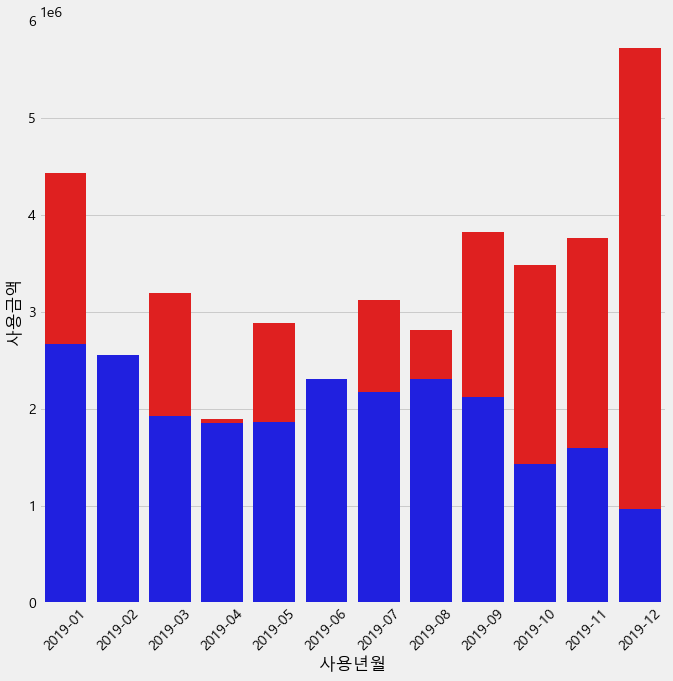

In [55]:
# 바 그래프
plt.figure(figsize=(10, 10))
sns.barplot(x='사용년월', y='사용금액', data=df_group_month[df_group_month['사용자']=='의장'], color='red')
sns.barplot(x='사용년월', y='사용금액', data=df_group_month[df_group_month['사용자']=='부의장'], color='blue')

plt.xticks(rotation=45)
plt.show()

In [56]:
df_group_month[df_group_month['사용년월']=='2019-02']

,사용년월,사용자,사용금액
7,2019-02,도시건설위원장,1830400
8,2019-02,보건복지위원장,1701500
9,2019-02,부의장,2555200
10,2019-02,의장,2415200
11,2019-02,의회사무국,4010430
12,2019-02,의회운영위원장,554000
13,2019-02,행정재경위원장,990000


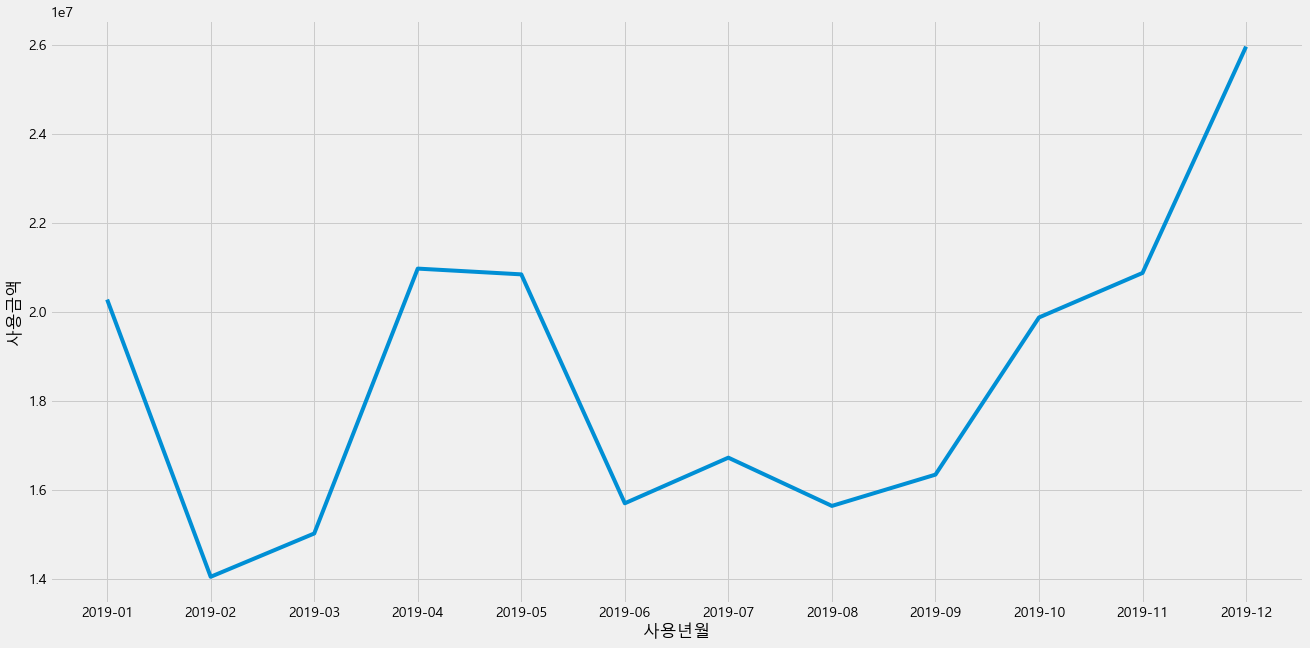

In [57]:
# 시계열 그래프
df.groupby('사용년월').sum()

plt.figure(figsize=(20, 10))
sns.lineplot(x='사용년월', y='사용금액', data=df.groupby('사용년월').sum().reset_index())
plt.show()

### 계절 컬럼 추가하기

+ 계절별 맛집 파악하기

In [58]:
df['계절'] = np.nan

for i in df.index:
    # 봄
    if (df.loc[i, '사용년월']=='2019-03') or (df.loc[i, '사용년월']=='2019-04') or (df.loc[i, '사용년월']=='2019-05'):
        df.loc[i, '계절'] = '봄'
    
    # 여름
    elif (df.loc[i, '사용년월']=='2019-06') or (df.loc[i, '사용년월']=='2019-07') or (df.loc[i, '사용년월']=='2019-08'):
        df.loc[i, '계절'] = '여름'
        
    # 가을
    elif (df.loc[i, '사용년월']=='2019-09') or (df.loc[i, '사용년월']=='2019-10') or (df.loc[i, '사용년월']=='2019-11'):
        df.loc[i, '계절'] = '가을'
    
    # 겨울
    elif (df.loc[i, '사용년월']=='2019-12') or (df.loc[i, '사용년월']=='2019-01') or (df.loc[i, '사용년월']=='2019-02'):
        df.loc[i, '계절'] = '겨울'

In [59]:
df[df['계절']=='봄']

,사용자,사용일시,사용금액,사용장소,주소,사용내역,사용년월,계절
194,의장,2019-03-05,144000,구름산원주추어탕,서울 관악구 관천로 47-1,의정활동 및 의회운영 관련 업무유대경비,2019-03,봄
195,의장,2019-03-05,270000,우리동네고기집,서울 관악구 인헌6길 24,의정활동 및 의회운영 관련 업무유대경비,2019-03,봄
196,의장,2019-03-06,39000,생각보다맛있는집,서울 관악구 관악로 152,의정활동 및 의회운영 관련 업무유대경비,2019-03,봄
197,의장,2019-03-06,15000,베리베리,서울 관악구 관악로 148,의정활동 및 의회운영 관련 업무유대경비,2019-03,봄
198,의장,2019-03-07,72000,제주은갈치,서울 관악구 관악로 139,의정활동 및 의회운영 관련 업무유대경비,2019-03,봄
...,...,...,...,...,...,...,...,...
1473,의회사무국,2019-05-31,225240,신세계페이먼츠,서울 중구 남대문시장10길 2,의원연구실 소요물품(다과) 구입,2019-05,봄
1474,의회사무국,2019-05-31,345000,장보고마트,서울 관악구 남부순환로230길,의원연구실 소요물품(다과) 구입,2019-05,봄
1475,의회사무국,2019-05-31,38000,파리바게뜨,서울 관악구 은천로 86,의회업무 추진을 위한 직원 및 관계자 간담회 등,2019-05,봄
1476,의회사무국,2019-05-31,190000,시골집,서울 관악구 낙성대로 22-8,사무국 직원 격려,2019-05,봄


In [60]:
# 봄
df[df['계절']=='봄']['사용장소'].value_counts().reset_index().head(10)

,index,사용장소
0,제주은갈치,22
1,옥천골,13
2,오리오리,12
3,시골집,12
4,감나무집,10
5,명태어장,8
6,파리바게뜨,8
7,청능장,7
8,남원추어탕,7
9,콩심,7


+ 다른 계절도 확인해보자

In [61]:
# 여름
df[df['계절']=='여름']['사용장소'].value_counts().reset_index().head(10)

,index,사용장소
0,제주은갈치,20
1,옛날육개장,13
2,옥천골,11
3,파리바게뜨,9
4,쌈마을,8
5,하이보,8
6,시골집,8
7,해물나라,7
8,장보고마트,7
9,콩심,7


In [62]:
# 가을
df[df['계절']=='가을']['사용장소'].value_counts().reset_index().head(10)

,index,사용장소
0,제주은갈치,21
1,시골집,15
2,산야로,14
3,하이보,11
4,옥천골,11
5,남원추어탕,9
6,은성숯불갈비,9
7,옛날육개장,9
8,페리카나,9
9,파리바게뜨,7


In [63]:
# 겨울
df[df['계절']=='겨울']['사용장소'].value_counts().reset_index().head(10)

,index,사용장소
0,제주은갈치,30
1,감나무집,14
2,남원추어탕,13
3,시골집,10
4,우리동네고기집,9
5,파리바게뜨,9
6,쌈마을,8
7,산야로,7
8,생각보다맛있는집,7
9,쟝블랑제리,6


In [64]:
df.groupby('계절').sum()

,사용금액
계절,
가을,57116050
겨울,60308480
봄,56860120
여름,48089730


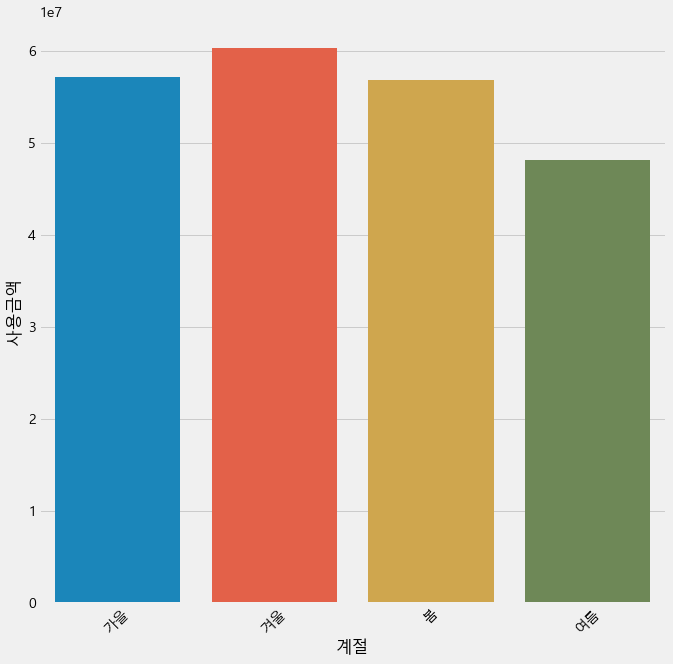

In [65]:
# 바 그래프
plt.figure(figsize=(10, 10))
sns.barplot(x='계절', y='사용금액', data=df.groupby('계절').sum().reset_index())
plt.xticks(rotation=45)
plt.show()

## 카테고리 컬럼별 데이터 확인하기

+ 3번이상 방문한 곳을 기준으로 카테고리 추가

In [66]:
df2.shape

(556, 3)

In [67]:
df2[df2['방문횟수']>7].shape

(59, 3)

In [68]:
# 방문횟수 8이상
(59 / 557) * 100 # 상위 10%

10.59245960502693

In [69]:
df2[df2['방문횟수']>3].shape

(127, 3)

In [70]:
# 방문횟수 4이상
(127 / 557) * 100 # 상위 20%

22.800718132854577

In [71]:
df3 = df2[df2['방문횟수']>3]
df3.index = range(len(df3))
df3

,사용장소,방문횟수,사용금액
0,(주)신세계페이먼츠,4,546290
1,11번가,4,232240
2,GS슈퍼마켓,4,381680
3,가마솥,4,224000
4,감나무집,33,6527500
...,...,...,...
122,해물나라,17,1892000
123,홍콩반점,7,278500
124,황복,6,390000
125,후포리,4,535000


### 데이터 저장하기

In [72]:
# df3.to_csv('./dataset/업무추진비_사용장소별_over3.csv', index=False)

In [94]:
df_cate = pd.read_csv('./dataset/업무추진비_사용장소별_카테고리_최종.csv')
df_cate

,사용장소,방문횟수,사용금액,카테고리
0,(주)신세계페이먼츠,4,546290,-
1,11번가,4,232240,-
2,GS슈퍼마켓,4,381680,-
3,가마솥,4,224000,보양식
4,감나무집,33,6527500,한식
...,...,...,...,...
122,해물나라,17,1892000,해물
123,홍콩반점,7,278500,중식
124,황복,6,390000,보양식
125,후포리,4,535000,해물


In [95]:
df_cate = df_cate[df_cate['카테고리']!='-']
df_cate.index = range(len(df_cate))
df_cate

,사용장소,방문횟수,사용금액,카테고리
0,가마솥,4,224000,보양식
1,감나무집,33,6527500,한식
2,강강술래,21,5068500,고기
3,강촌민물매운탕2호점,7,547000,해물
4,갯바위,6,458000,해물
...,...,...,...,...
114,해물나라,17,1892000,해물
115,홍콩반점,7,278500,중식
116,황복,6,390000,보양식
117,후포리,4,535000,해물


### 카테고리 수정

+ 해물 → 해물, 생선요리
    - 해물이라는 카테고리가 음식점 전부를 대표하기 부족한 부분이 있어 생선요리를 포함한 카테고리로 수정

In [106]:
# df_cate[df_cate['카테고리']=='해물']['카테고리'].apply(lambda x: x + ', 생선요리')

3      해물, 생선요리
4      해물, 생선요리
7      해물, 생선요리
17     해물, 생선요리
21     해물, 생선요리
30     해물, 생선요리
33     해물, 생선요리
36     해물, 생선요리
58     해물, 생선요리
64     해물, 생선요리
79     해물, 생선요리
91     해물, 생선요리
92     해물, 생선요리
114    해물, 생선요리
117    해물, 생선요리
Name: 카테고리, dtype: object

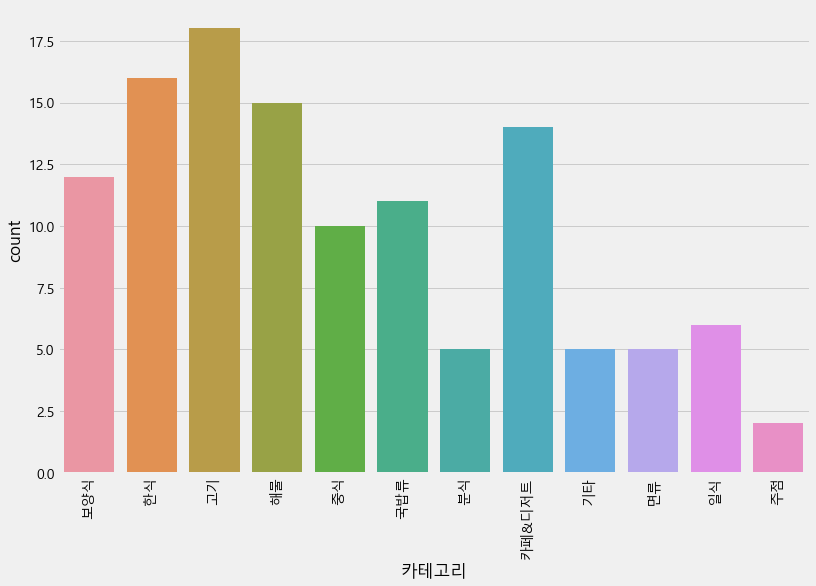

In [97]:
plt.figure(figsize=(12, 8))
sns.countplot(x='카테고리', data=df_cate)
plt.xticks(rotation=90)
plt.show()

In [76]:
df_cate.groupby('카테고리').count()

,사용장소,방문횟수,사용금액
카테고리,,,
고기,18,18,18
국밥류,11,11,11
기타,5,5,5
면류,5,5,5
보양식,12,12,12
분식,5,5,5
일식,6,6,6
주점,2,2,2
중식,10,10,10


In [77]:
df_cate[df_cate['카테고리']=='주점']

,사용장소,방문횟수,사용금액,카테고리
82,작은따옴표,4,930000,주점
83,장군집,7,263000,주점


## 위치 데이터 추가

In [78]:
df_loc = pd.read_csv('./dataset/관악구 업무추진비 위치.csv')
df_loc

,사용장소,주소,사용금액,lat,lng,거리
0,#207,서울 관악구 원신길 128 #207,27200,37.506248,126.913952,4559.495385
1,(주)소명생고기,서울 금천구 시흥대로 264 (주)소명생고기,100000,37.457203,126.899928,5111.949204
2,(주)송원마포갈비,서울 영등포구 도림로147길 2-1 (주)송원마포갈비,45500,37.516644,126.889236,6969.211685
3,(주)신세계페이먼츠,서울 중구 남대문시장10길 2 (주)신세계페이먼츠,546290,37.560333,126.982963,9555.694239
4,(주)신화아이푸드,충청북도 청주시 서원구 1순환로 886 (주)신화아이푸드,469500,36.616615,127.469836,106263.797527
...,...,...,...,...,...,...
586,흥부보쌈,서울 관악구 신림로59길 15-13 흥부보쌈,1167000,37.482655,126.929366,2019.981634
587,희로애락,서울 관악구 봉천로 465 희로애락,508000,37.482469,126.951614,486.587335
588,희전명가,서울 관악구 남부순환로180길 6 희전명가,88000,37.485211,126.931504,1935.672971
589,히포커피,서울 관악구 신림로23길 21 히포커피,10800,37.469969,126.934968,1717.771051


In [79]:
for i in df_loc.index:
    if df_loc.loc[i, '사용장소']=='GS슈퍼':
        df_loc.loc[i, '사용장소'] = 'GS슈퍼마켓'
    elif df_loc.loc[i, '사용장소']=='강강술래신림본동점':
        df_loc.loc[i, '사용장소'] = '강강술래'
    elif df_loc.loc[i, '사용장소']=='강촌민물매운탕２호점':
        df_loc.loc[i, '사용장소'] = '강촌민물매운탕2호점'
    elif df_loc.loc[i, '사용장소']=='고봉민김밥인':
        df_loc.loc[i, '사용장소'] = '고봉민김밥'
    elif df_loc.loc[i, '사용장소']=='김가네 관악구청점':
        df_loc.loc[i, '사용장소'] = '김가네'

    
    
    elif df_loc.loc[i, '사용장소']=='동강영양탕':
        df_loc.loc[i, '사용장소'] = '동강염소탕'
    elif df_loc.loc[i, '사용장소']=='맛고을칼국수＆찰보리':
        df_loc.loc[i, '사용장소'] = '맛고을칼국수＆찰보리밥'
    elif df_loc.loc[i, '사용장소']=='먹쉬돈나 서울대역점':
        df_loc.loc[i, '사용장소'] = '먹쉬돈나'
    elif df_loc.loc[i, '사용장소']=='명태어장(서울대점)':
        df_loc.loc[i, '사용장소'] = '명태어장'
    elif df_loc.loc[i, '사용장소']=='명품청기와감자탕미성점':
        df_loc.loc[i, '사용장소'] = '명품청기와감자탕'
    elif df_loc.loc[i, '사용장소']=='미가할매참품한우':
        df_loc.loc[i, '사용장소'] = '미가할매집'
    elif df_loc.loc[i, '사용장소']=='바우네나주곰탕　봉천':
        df_loc.loc[i, '사용장소'] = '바우네나주곰탕'
        

        
        
    elif df_loc.loc[i, '사용장소']=='봉이 구이대장':
        df_loc.loc[i, '사용장소'] = '봉이구이대장'
    elif df_loc.loc[i, '사용장소']=='사시사철흑염소.오리':
        df_loc.loc[i, '사용장소'] = '사시사철흑염소오리'
        
        

    
    elif (df_loc.loc[i, '사용장소']=='엔조파스타&피자') or (df_loc.loc[i, '사용장소']=='ENZO(엔조)'):
        df_loc.loc[i, '사용장소'] = '엔조 파스타&피자'
        
        
    elif (df_loc.loc[i, '사용장소']=='영광수산장어1번가') or (df_loc.loc[i, '사용장소']=='영광수산장어１번가'):
        df_loc.loc[i, '사용장소'] = '영광수산숯불민물장어'
    
    
    elif (df_loc.loc[i, '사용장소']=='이대감명품막창') or (df_loc.loc[i, '사용장소']=='이대감왕족발'):
        df_loc.loc[i, '사용장소'] = '이대감 명품막창'
    
    elif (df_loc.loc[i, '사용장소']=='일커피　서울대입구점') or (df_loc.loc[i, '사용장소']=='일커피 서울대입구점'):
        df_loc.loc[i, '사용장소'] = '일커피'
                                            
    elif (df_loc.loc[i, '사용장소']=='자연별곡 서울대입구점') or (df_loc.loc[i, '사용장소']=='자연별곡서울대입구점'):
        df_loc.loc[i, '사용장소'] = '자연별곡'
    
    elif (df_loc.loc[i, '사용장소']=='작은따옴표 협동조합') or (df_loc.loc[i, '사용장소']=='작은따옴표협동조합'):
        df_loc.loc[i, '사용장소'] = '작은따옴표'
        
    elif (df_loc.loc[i, '사용장소']=='커피빈') or (df_loc.loc[i, '사용장소']=='커피빈코리아인'):
        df_loc.loc[i, '사용장소'] = '커피빈코리아'
        
    elif (df_loc.loc[i, '사용장소']=='콩심 서울대점') or (df_loc.loc[i, '사용장소']=='콩심서울대점'):
        df_loc.loc[i, '사용장소'] = '콩심'
        
        
    
    elif df_loc.loc[i, '사용장소']=='종로계림닭도리탕':
        df_loc.loc[i, '사용장소'] = '종로계림닭도리탕원조'
        
    elif df_loc.loc[i, '사용장소']=='진부령　황태촌':
        df_loc.loc[i, '사용장소'] = '진부령황태촌'    
    
    elif df_loc.loc[i, '사용장소']=='진우리참치':
        df_loc.loc[i, '사용장소'] = '진우리독도참치'    
        
    elif df_loc.loc[i, '사용장소']=='카페모아관악구청점':
        df_loc.loc[i, '사용장소'] = '카페모아'    
    
    elif df_loc.loc[i, '사용장소']=='쿠팡㈜':
        df_loc.loc[i, '사용장소'] = '쿠팡'       
    
    elif df_loc.loc[i, '사용장소']=='태창약국':
        df_loc.loc[i, '사용장소'] = '태창온누리약국'     
    
    elif df_loc.loc[i, '사용장소']=='투썸플레이스':
        df_loc.loc[i, '사용장소'] = '투썸서울대입구역'       
        
        
    elif (df_loc.loc[i, '사용장소']=='난곡문성파리바게뜨') or (df_loc.loc[i, '사용장소']=='난곡사거리 파리바게뜨'):
        df_loc.loc[i, '사용장소'] = '파리바게뜨'
    
    elif (df_loc.loc[i, '사용장소']=='서울대 파리바게뜨') or (df_loc.loc[i, '사용장소']=='서울대입구역2호 파리바게뜨'):
        df_loc.loc[i, '사용장소'] = '파리바게뜨'
    elif (df_loc.loc[i, '사용장소']=='은천길입구 파리바게뜨') or (df_loc.loc[i, '사용장소']=='파리바게뜨서울대입구'):
        df_loc.loc[i, '사용장소'] = '파리바게뜨'
    elif (df_loc.loc[i, '사용장소']=='파리바게트'):
        df_loc.loc[i, '사용장소'] = '파리바게뜨'
    
    elif (df_loc.loc[i, '사용장소']=='본죽 관악구청점') or (df_loc.loc[i, '사용장소']=='본죽&본도시락'):
        df_loc.loc[i, '사용장소'] = '본죽'
    elif (df_loc.loc[i, '사용장소']=='본죽&비빔밥') or (df_loc.loc[i, '사용장소']=='본죽봉천점'):
        df_loc.loc[i, '사용장소'] = '본죽'   
    elif (df_loc.loc[i, '사용장소']=='본죽＆비빔밥') or (df_loc.loc[i, '사용장소']=='본죽＆비빔밥ｃａｆｅ'):
        df_loc.loc[i, '사용장소'] = '본죽'
          
          
    elif (df_loc.loc[i, '사용장소']=='서울대학교생협호암교수회관') or (df_loc.loc[i, '사용장소']=='서울대학교생활협동조'):
        df_loc.loc[i, '사용장소'] = '서울대학교'
          
          
    elif (df_loc.loc[i, '사용장소']=='스타벅스 서울대입구역점'):
        df_loc.loc[i, '사용장소'] = '스타벅스'
    
    elif (df_loc.loc[i, '사용장소']=='아웃백') or (df_loc.loc[i, '사용장소']=='아웃백스테이크'):
        df_loc.loc[i, '사용장소'] = '아웃백스테이크하우스'
    
    elif (df_loc.loc[i, '사용장소']=='삼백돈'):
        df_loc.loc[i, '사용장소'] = '삼백돈돈가츠'      
    elif (df_loc.loc[i, '사용장소']=='두부이야기봉천점'):
        df_loc.loc[i, '사용장소'] = '두부이야기'
    elif (df_loc.loc[i, '사용장소']=='얼큰수제비') or (df_loc.loc[i, '사용장소']=='얼큰수제비 해물칼국수'):
        df_loc.loc[i, '사용장소'] = '얼큰수제비해물칼국수'
        
    elif (df_loc.loc[i, '사용장소']=='얼큰수제비') or (df_loc.loc[i, '사용장소']=='얼큰수제비 해물칼국수'):
        df_loc.loc[i, '사용장소'] = '얼큰수제비해물칼국수'
    elif (df_loc.loc[i, '사용장소']=='풍년오리'):
        df_loc.loc[i, '사용장소'] = '풍년옥'     

In [80]:
# 중복 데이터 삭제
df_loc.drop_duplicates(['사용장소'], inplace=True)
df_loc.index = range(len(df_loc))
df_loc

,사용장소,주소,사용금액,lat,lng,거리
0,#207,서울 관악구 원신길 128 #207,27200,37.506248,126.913952,4559.495385
1,(주)소명생고기,서울 금천구 시흥대로 264 (주)소명생고기,100000,37.457203,126.899928,5111.949204
2,(주)송원마포갈비,서울 영등포구 도림로147길 2-1 (주)송원마포갈비,45500,37.516644,126.889236,6969.211685
3,(주)신세계페이먼츠,서울 중구 남대문시장10길 2 (주)신세계페이먼츠,546290,37.560333,126.982963,9555.694239
4,(주)신화아이푸드,충청북도 청주시 서원구 1순환로 886 (주)신화아이푸드,469500,36.616615,127.469836,106263.797527
...,...,...,...,...,...,...
544,흥부보쌈,서울 관악구 신림로59길 15-13 흥부보쌈,1167000,37.482655,126.929366,2019.981634
545,희로애락,서울 관악구 봉천로 465 희로애락,508000,37.482469,126.951614,486.587335
546,희전명가,서울 관악구 남부순환로180길 6 희전명가,88000,37.485211,126.931504,1935.672971
547,히포커피,서울 관악구 신림로23길 21 히포커피,10800,37.469969,126.934968,1717.771051


In [81]:
for i in tqdm(df_cate.index):
    for j in tqdm(df_loc.index):
        if df_cate.loc[i, '사용장소']==df_loc.loc[j, '사용장소']:
            df_cate.loc[i, '주소'] = df_loc.loc[j, '주소']
            df_cate.loc[i, 'lat'] = df_loc.loc[j, 'lat']
            df_cate.loc[i, 'lng'] = df_loc.loc[j, 'lng']            

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 21173.03it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 30584.05it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 22021.45it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 18362.48it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 22018.92it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 25021.71it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 25021.17it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 26831.74it/s]

100%|███████████████████████████

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 17758.08it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 19659.46it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 19660.80it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 39317.57it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 36700.08it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 30583.23it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 30583.23it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 32382.30it/s]

100%|███████████████████████████

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 30582.83it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 27524.18it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 36703.59it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 32384.58it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 30584.86it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 32387.31it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 22019.55it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 39322.94it/s]

100%|███████████████████████████

In [82]:
df_cate

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
0,가마솥,4,224000,보양식,서울 관악구 관악로17길 13 가마솥,37.480721,126.951002
1,감나무집,33,6527500,한식,서울 관악구 관악로11길 20 감나무집,37.477906,126.951002
2,강강술래,21,5068500,고기,서울 관악구 남부순환로 1660 강강술래,37.484604,126.935058
3,강촌민물매운탕2호점,7,547000,해물,서울 동작구 보라매로5길 15 강촌민물매운탕2호점,37.498098,126.920755
4,갯바위,6,458000,해물,서울 관악구 남부순환로216길 13 갯바위,37.480840,126.949110
...,...,...,...,...,...,...,...
114,해물나라,17,1892000,해물,서울 관악구 남부순환로 1674 해물나라,37.469685,126.933227
115,홍콩반점,7,278500,중식,서울 관악구 관악로 152 홍콩반점,37.478742,126.952557
116,황복,6,390000,보양식,서울 관악구 봉천로 356 황복,37.483903,126.939363
117,후포리,4,535000,해물,서울 관악구 봉천로 388 후포리,37.482873,126.943077


In [83]:
df_cate.isnull().sum()

사용장소    0
방문횟수    0
사용금액    0
카테고리    0
주소      1
lat     1
lng     1
dtype: int64

In [84]:
df_cate[df_cate['주소'].isnull()]

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
84,장수삼계탕,6,180000,보양식,NaN,NaN,NaN


In [85]:
# 장수삼계탕
df_cate.loc[84, ['주소', 'lat', 'lng']] ='서울특별시 관악구 봉천동 봉천로 486 장수삼계탕', 37.48199329778763, 126.9536346388275

In [86]:
df_cate.isnull().sum()

사용장소    0
방문횟수    0
사용금액    0
카테고리    0
주소      0
lat     0
lng     0
dtype: int64

In [87]:
df_cate[df_cate['사용장소']=='장수삼계탕']

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
84,장수삼계탕,6,180000,보양식,서울특별시 관악구 봉천동 봉천로 486 장수삼계탕,37.481993,126.953635


### 데이터 저장하기

In [88]:
# df_cate.to_csv('./dataset/업무추진비_지도.csv', index=False)